Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
import matplotlib.cm as cm
import matplotlib.patheffects as pe
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Importing Enthalpy and Entropy Data
Accessed from NIST WebBook

In [2]:
OD=Path("data") / "OrganicCompoundHS.xlsx"
orgHSdataimp=pd.read_excel(OD, skiprows=5)
orgHSdatatot=pd.DataFrame(orgHSdataimp)
orgHSdatatot["Family"]=orgHSdatatot["Family"].ffill()

def parse_formulas(formula): 
    while "(" in formula: 
        match =re.search(r"\(([A-Za-z0-9]+)\)(\d+)", formula)
        if not match: 
            break
        group, mult = match.groups()
        mult=int(mult)
        expanded="".join([group] * mult)
        formula=formula.replace(match.group(0), expanded, 1)
        
    matches=re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    counts={}
    for elem, num in matches: 
        counts[elem] = counts.get(elem, 0) + int(num) if num else counts.get(elem, 0) + 1
    return counts

orgHSdatatot["parsed"]=orgHSdatatot["Formula"].apply(parse_formulas)
orgHSdatatot["C"]=orgHSdatatot["parsed"].apply(lambda x: x.get("C", 0))
orgHSdatatot["H"]=orgHSdatatot["parsed"].apply(lambda x: x.get("H", 0))
orgHSdatatot["O"]=orgHSdatatot["parsed"].apply(lambda x: x.get("O", 0))
orgHSdata=orgHSdatatot.drop(["parsed"], axis=1)
# print(orgHSdata.to_string(index=False))

## Standard Entropy of Formation Calculation
Subtract entropies of carbon, H2 and O2 from the standard entropy of each compound at 298 K (25C)

In [3]:
entropy=pd.DataFrame({
    "Compound": ["C", "H2", "O2"], 
    "S0 (J/mol K)": [5.833, 130.68, 205.15]
})
elem=entropy.set_index("Compound")["S0 (J/mol K)"]
w=pd.Series({
    "C": elem["C"], 
    "H": elem["H2"]/2, 
    "O": elem["O2"]/2
})
orgHSdata["delS_F (J/mol K)"]=orgHSdata["S0 (J/molK)"] - (orgHSdata[["C", "H", "O"]] @ w)

## Gibbs Free Energy of Formation Calculation
Using G=H-TS equation with values of H_F (kJ/mol) and S_F (J/mol K) at 298.15 K
Some compounds do not have G_F values readily available, this is to keep all values consistent.

In [4]:
T0=298.15 #K
orgHSdata["G_F (kJ/mol)"]=orgHSdata["ΔHf (kJ/mol)"] - T0*(orgHSdata["delS_F (J/mol K)"]/1000)

## G_F - H_F Plot

Plotting G_F vs H_F of each compound studied. 

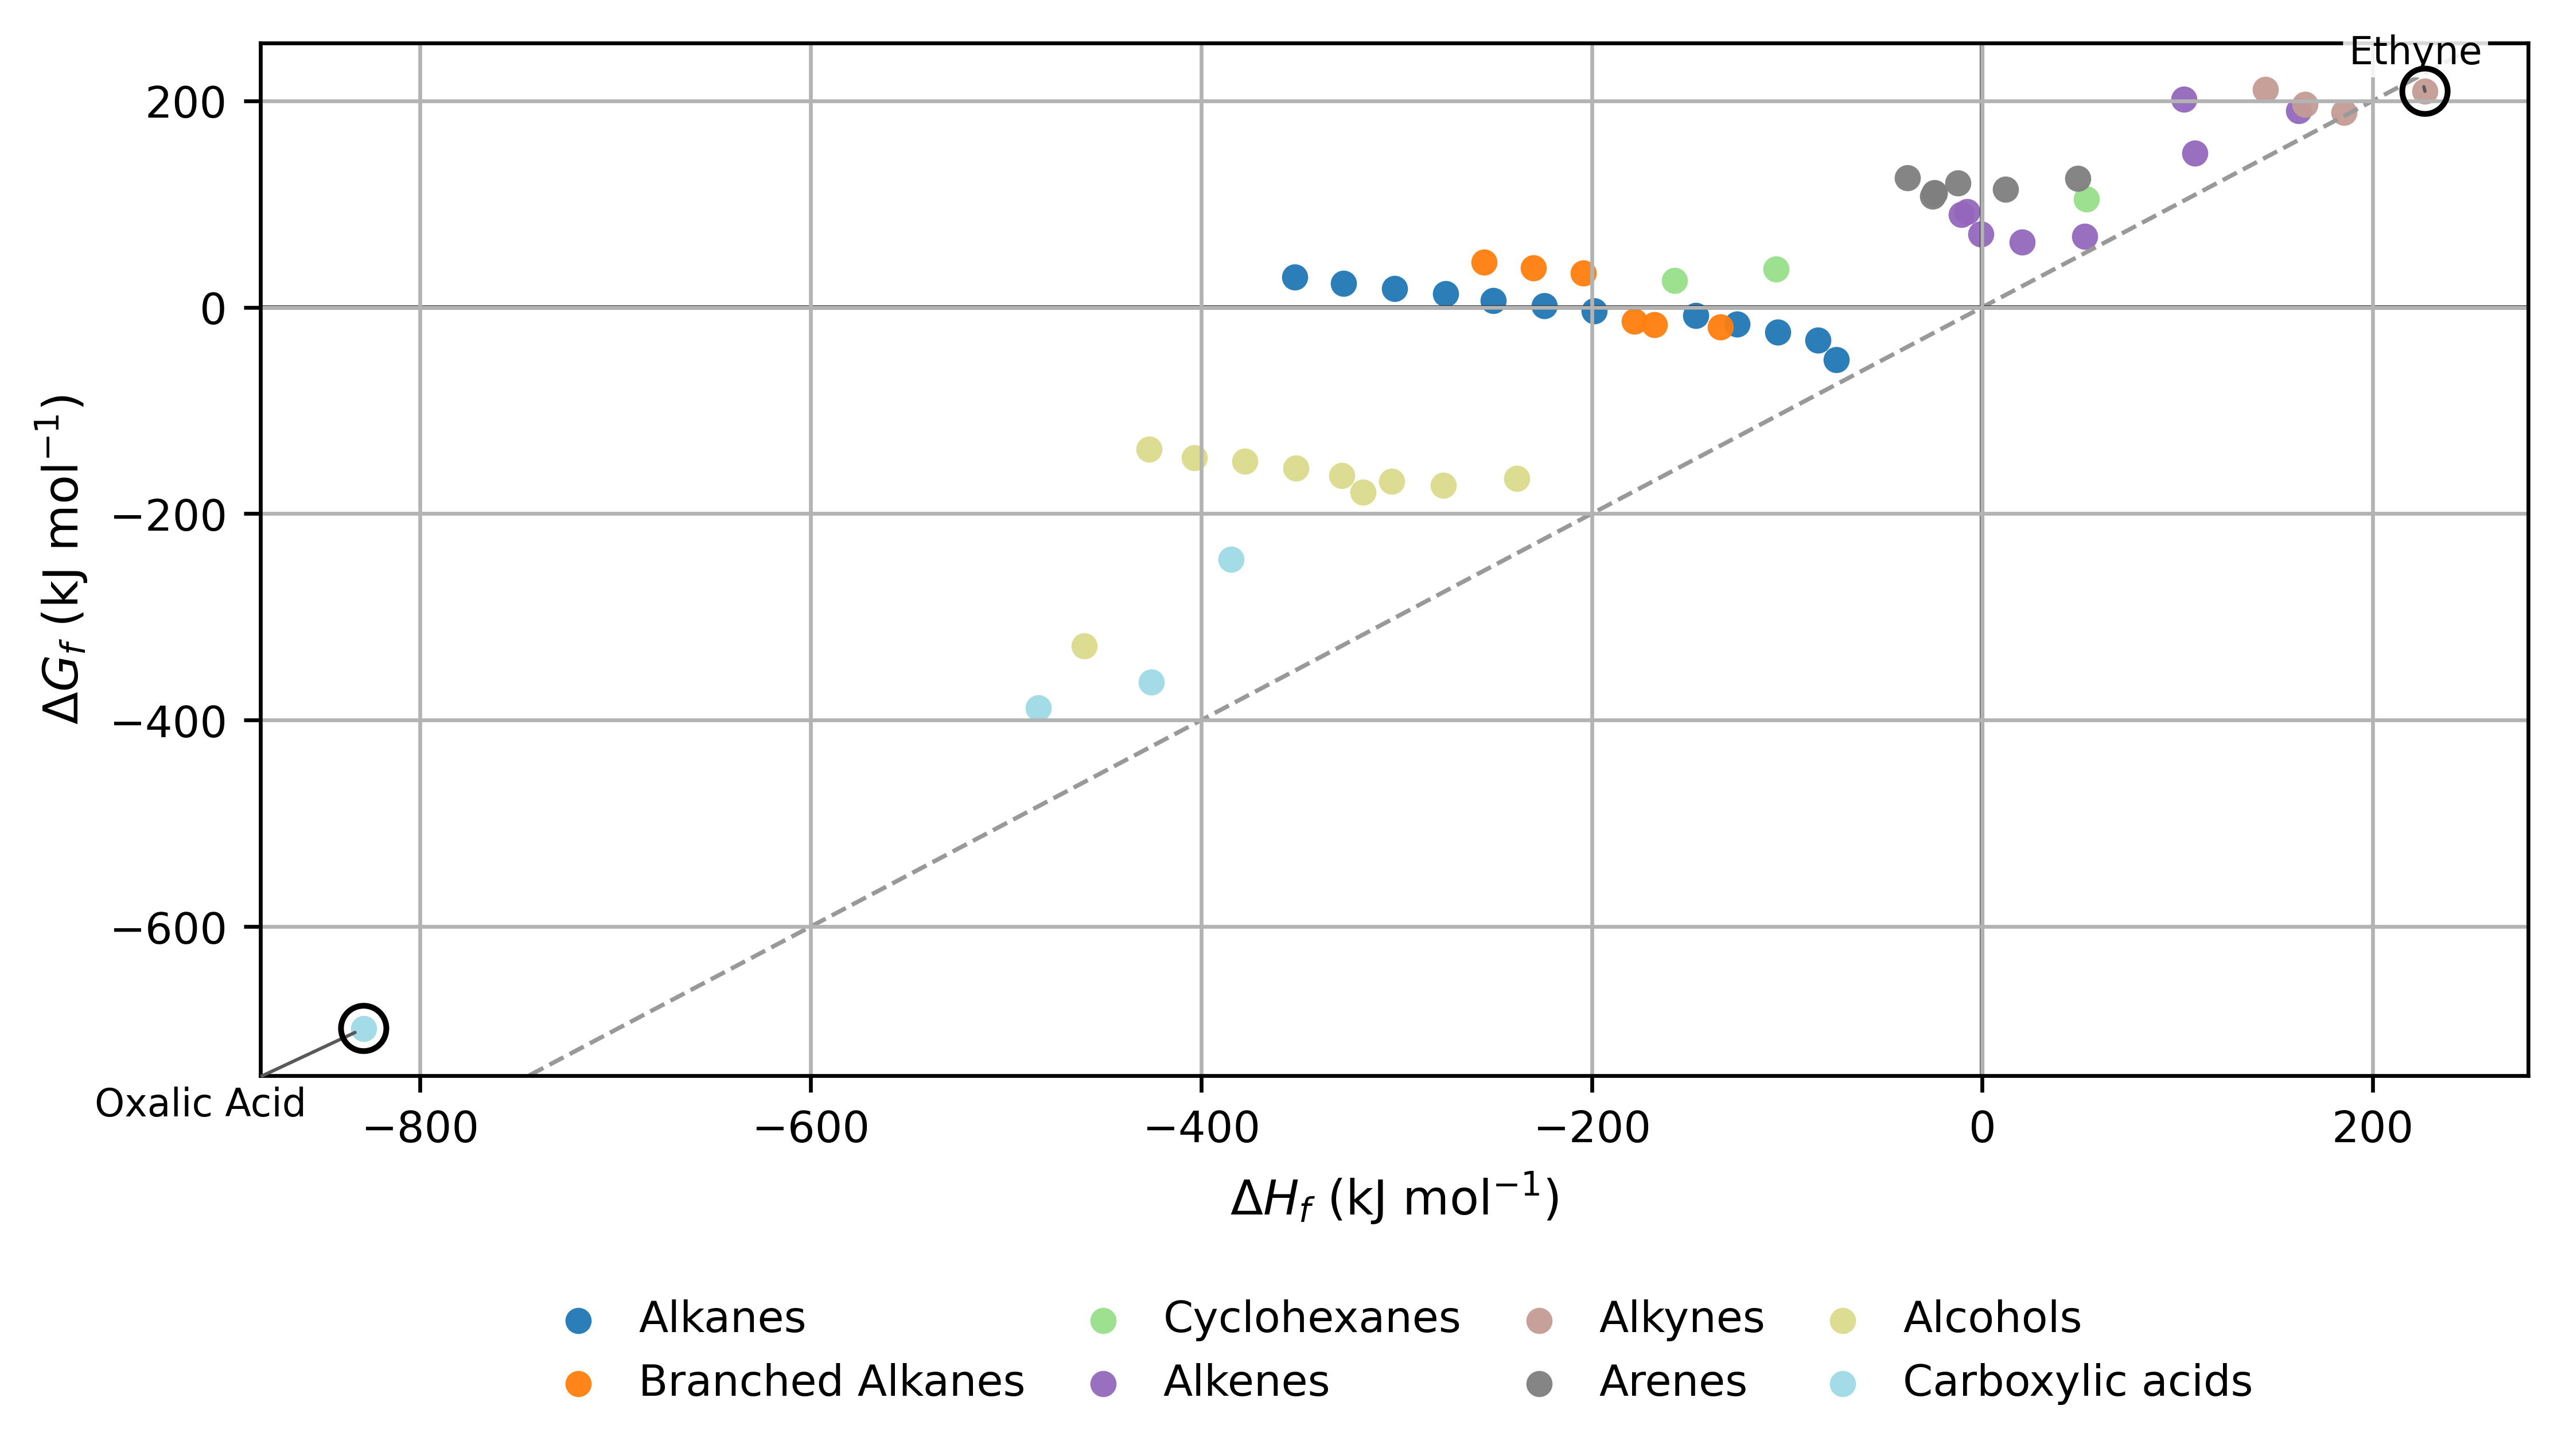

In [5]:
plt.rcParams.update({
    "font.size": 10, 
    "axes.titlesize": 11, 
    "axes.labelsize": 10, 
    "xtick.labelsize": 9, 
    "ytick.labelsize": 9, 
    "legend.fontsize": 9, 
    "axes.linewidth": 0.8,
})

orgcopy = orgHSdata.copy()
H_col = 'ΔHf (kJ/mol)'
G_col = 'G_F (kJ/mol)'

# Clean once
for c in [H_col, G_col]:
    orgcopy[c] = pd.to_numeric(orgcopy[c], errors='coerce')
df = orgcopy.dropna(subset=[H_col, G_col]).copy()

# Prepare data arrays
x = df[H_col].to_numpy()
y = df[G_col].to_numpy()

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=600)

# Color by Family
families = df['Family'].dropna().unique()
colors = cm.tab20(np.linspace(0, 1, len(families)))
for fam, color in zip(families, colors):
    fam_df = df[df['Family'] == fam]
    ax.scatter(fam_df[H_col], fam_df[G_col], color=color, s=30, label=fam, alpha=0.95, linewidths=0)

idx_min = (df[H_col] + df[G_col]).idxmin()
idx_max = (df[H_col] + df[G_col]).idxmax()
pt_min = df.loc[idx_min]
pt_max = df.loc[idx_max]

ax.scatter(
    pt_min[H_col], pt_min[G_col], 
    s=90, facecolor="none", edgecolor="black", 
    linewidth=1.2, zorder=10
)
ax.annotate(pt_min["Compound"], 
            (pt_min[H_col], pt_min[G_col]), 
            xytext=(-12, -12), textcoords="offset points", 
            ha="right", va="top", 
            fontsize=8, 
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85), 
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.35"))

ax.scatter(
    pt_max[H_col], pt_max[G_col], 
    s=90, facecolor="none", edgecolor="black", 
    linewidth=1.2, zorder=10
)
ax.annotate(pt_max["Compound"], 
            (pt_max[H_col], pt_max[G_col]), 
            xytext=(12, 12), textcoords="offset points", 
            ha="right", va="top", 
            fontsize=8, 
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85), 
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.35"))

# Axes helpers
ax.axline((0,0), slope=1, linestyle='--', linewidth=0.9, color="0.6", zorder=1)
ax.axhline(0, color='0.1', linewidth=0.9, zorder=1)
ax.axvline(0, color='0.1', linewidth=0.9, zorder=1)
ax.set_xlabel(r"$\Delta H_f$ (kJ mol$^{-1}$)")
ax.set_ylabel(r"$\Delta G_f$ (kJ mol$^{-1}$)")
leg = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=False, 
    handletextpad=0.4, 
    columnspacing=0.8, 
    borderaxespad=0.0)
ax.grid(True, linewidth=0.8, color='0.7')
fig.subplots_adjust(bottom=0.28)
# plt.savefig("GFvsHFOrgNoFit.png", dpi=1200, bbox_inches="tight")
plt.show()

## CO2 + H2O (L) -> CxHyOz + O2 Reaction

Assuming a liquid water basis so the value is correlated to HHV, will form each component from previous section

In [6]:
stdthermo=pd.DataFrame({
    "Compound": ["CO2", "H2O", "O2"], 
    "G_F (kJ/mol)": [-394.36, -237.14, 0], 
    "H_F (kJ/mol)": [-393.51, -285.83, 0]
})

def LHVreactcalc(orgHSdata, stdthermo): 
    s=stdthermo.set_index(stdthermo.columns[0]) if stdthermo.columns[0] !="species" else stdthermo.set_index("species")
    for sp in ["CO2", "H2O", "O2"]: 
        if sp not in s.index:
            raise ValueError(f"Missing {sp} in stdthermo index/first column")
    G_CO2, H_CO2 = s.loc["CO2", "G_F (kJ/mol)"], s.loc["CO2", "H_F (kJ/mol)"]
    G_H2O, H_H2O = s.loc["H2O", "G_F (kJ/mol)"], s.loc["H2O", "H_F (kJ/mol)"]
    G_O2, H_O2 = s.loc["O2", "G_F (kJ/mol)"], s.loc["O2", "H_F (kJ/mol)"]

    x=orgHSdata["C"]
    y=orgHSdata["H"]
    z=orgHSdata["O"]
    n_CO2=x
    n_H2O=y/2
    n_O2=x+y/4-z/2

    dG_rxn=-(n_CO2*G_CO2) - (n_H2O*G_H2O) + (n_O2*G_O2) + orgHSdata["G_F (kJ/mol)"]
    dH_rxn=-(n_CO2*H_CO2) - (n_H2O*H_H2O) + (n_O2*H_O2) + orgHSdata["ΔHf (kJ/mol)"]

    out=orgHSdata.copy()
    out["n_CO2"]=n_CO2
    out["n_H2O"]=n_H2O
    out["n_O2"]=n_O2
    out["dG_rxn (kJ/mol)"]=dG_rxn
    out["dH_rxn (kJ/mol)"]=dH_rxn
    return out

ORGresults=LHVreactcalc(orgHSdata, stdthermo)

## Plotting G_rxn vs H_rxn

Will allow us to see the correlation between G and H for combustion reactions of all organics studied

Intercept = -9.62 kJ/mol, Slope = 0.9725
R2 = 0.9997, MAE = 24.53 kJ/mol, RMSE = 31.25 kJ/mol, Median AE = 23.76 kJ/mol, MAPE = 1.71%


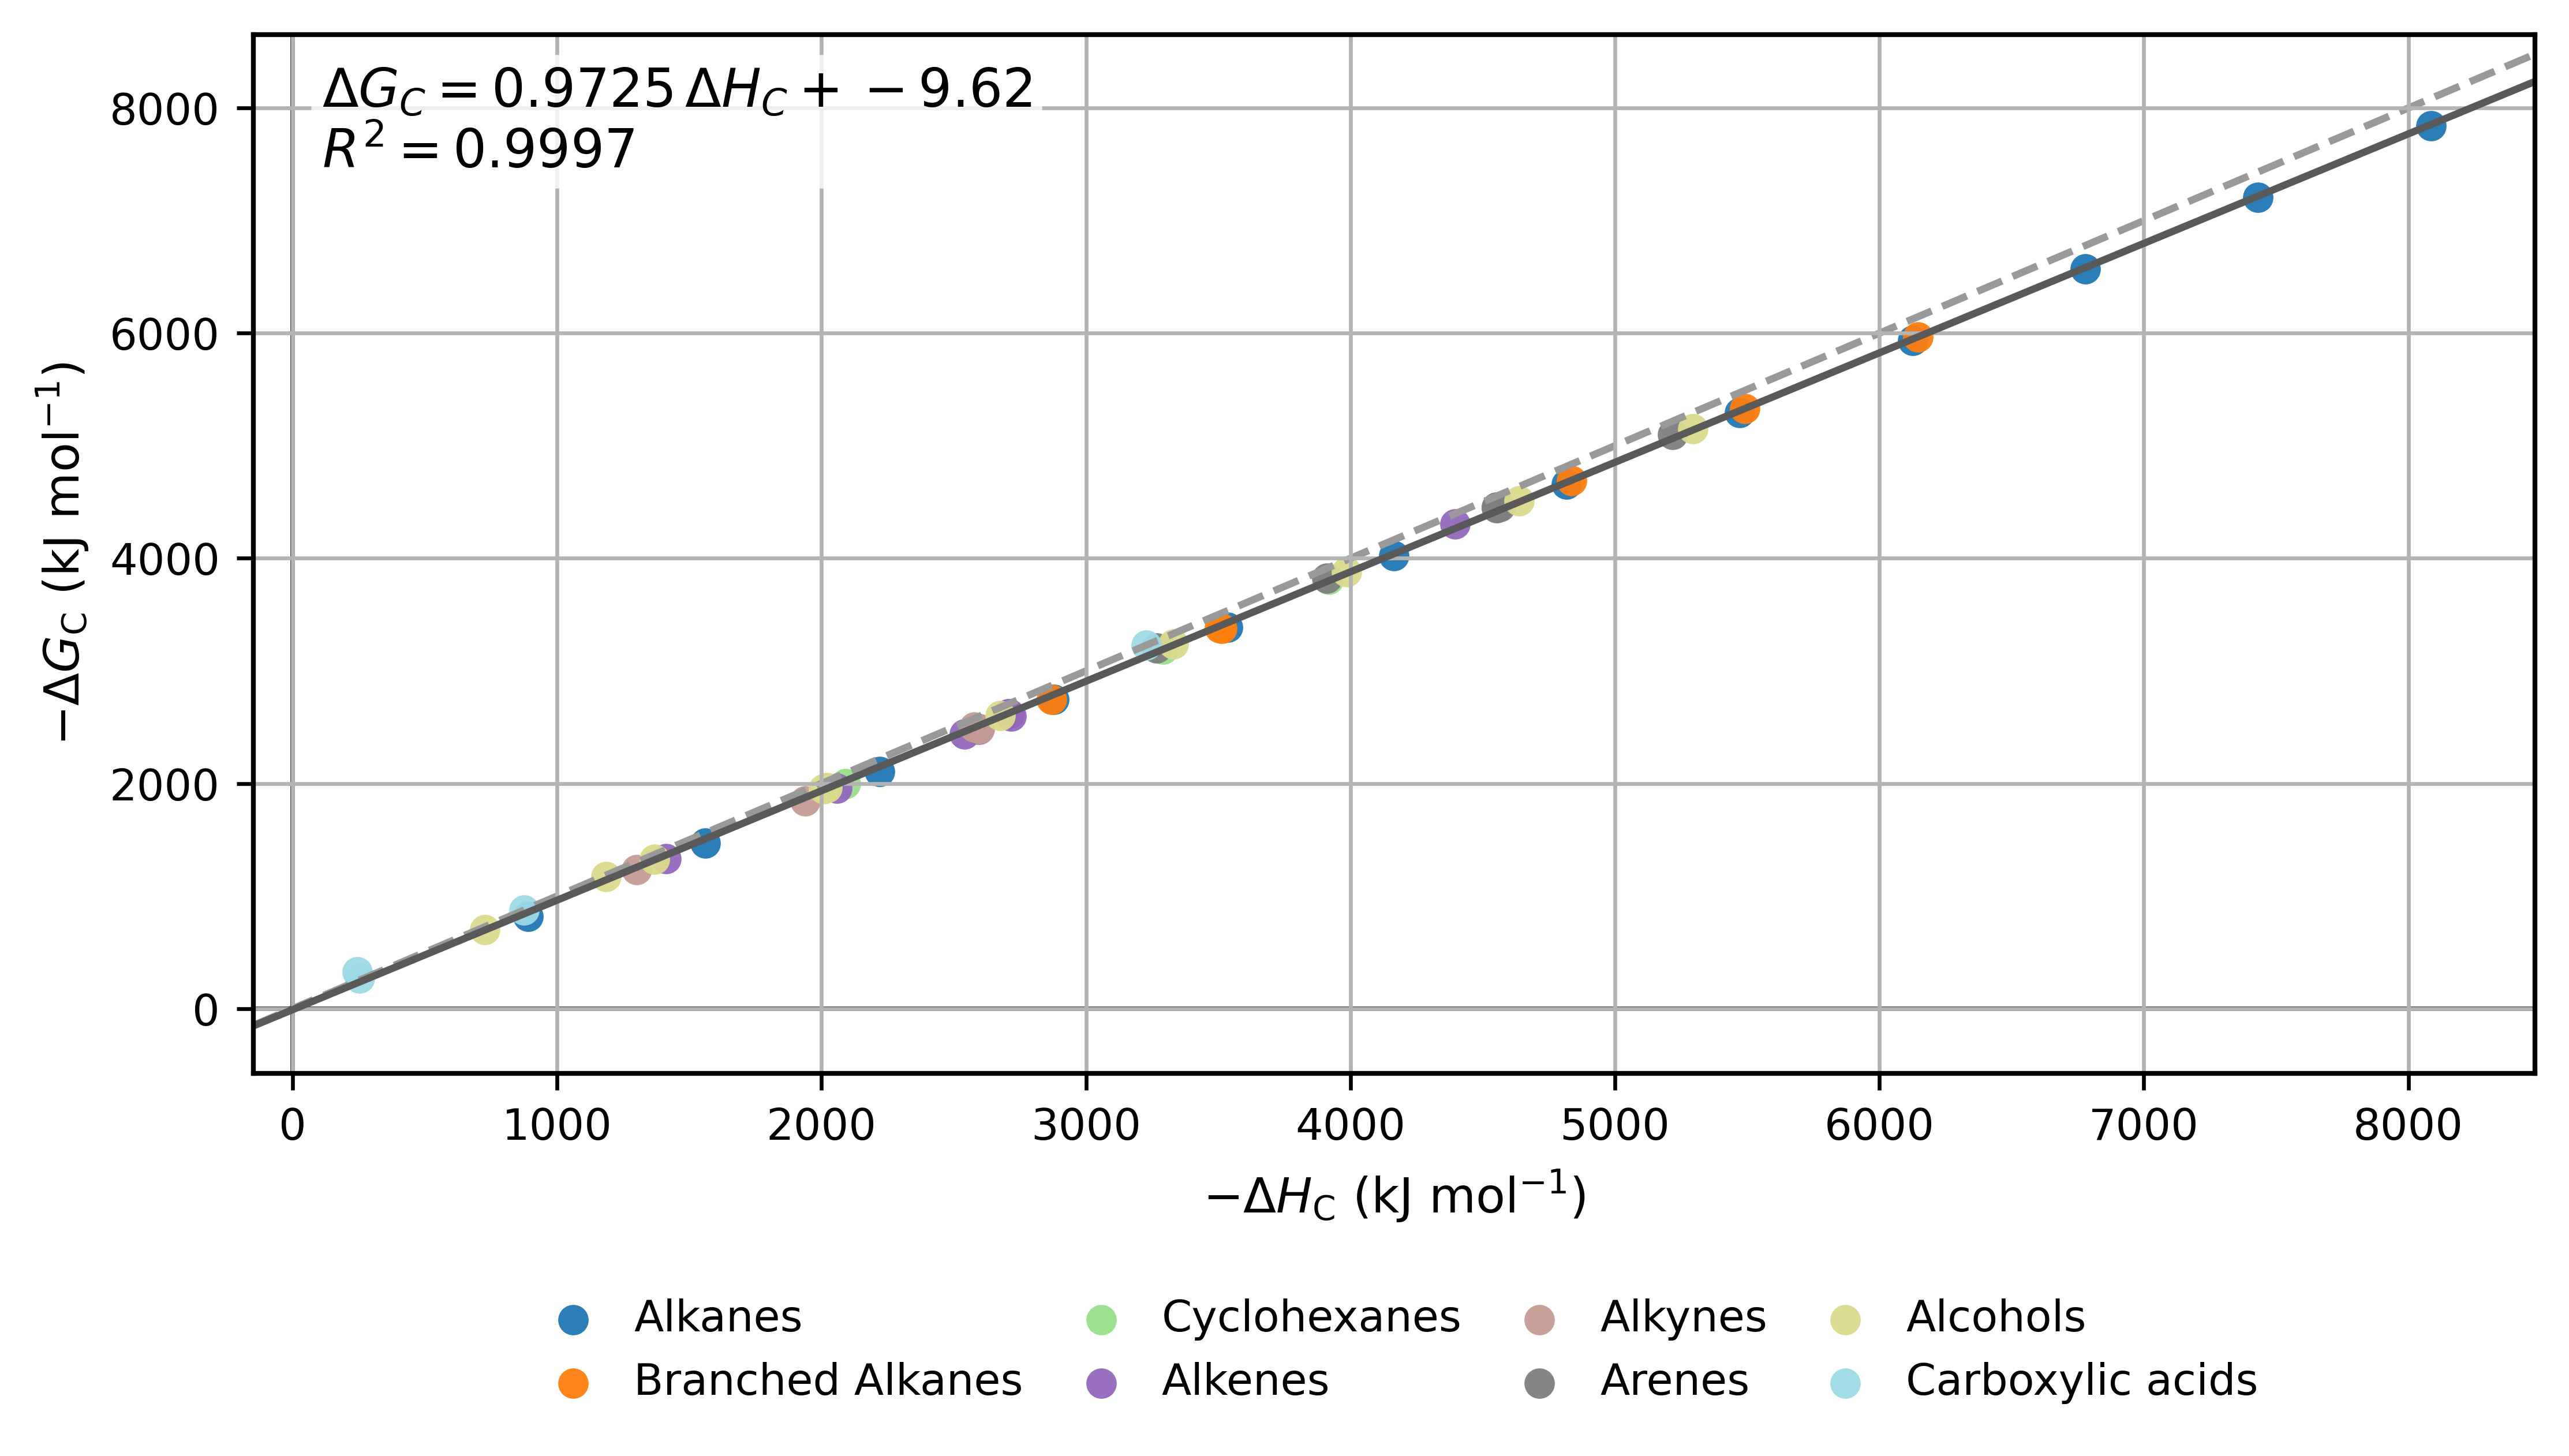

In [7]:
plt.rcParams.update({
    "font.size": 11, 
    "axes.titlesize": 11, 
    "axes.labelsize": 10, 
    "xtick.labelsize": 9, 
    "ytick.labelsize": 9, 
    "legend.fontsize": 9, 
    "axes.linewidth": 1,
})

xcol = "dH_rxn (kJ/mol)"
ycol = "dG_rxn (kJ/mol)"

df = ORGresults[[xcol, ycol, "Family"]].copy()
df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
df[ycol] = pd.to_numeric(df[ycol], errors="coerce")
df=df.dropna(subset=[xcol, ycol])

X=df[[xcol]].to_numpy()
y=df[ycol].to_numpy()

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=600)

# Color by Family
families = ORGresults['Family'].dropna().unique()
colors = cm.tab20(np.linspace(0, 1, len(families)))
for fam, color in zip(families, colors):
    fam_df = ORGresults[ORGresults['Family'] == fam]
    ax.scatter(fam_df[xcol], fam_df[ycol], color=color, s=40, label=fam, alpha=0.95, linewidths=0)

model=LinearRegression().fit(X, y)
b=model.intercept_
m=model.coef_[0]
yhat = model.predict(X)

mae = mean_absolute_error(y, yhat)
mse = mean_squared_error(y, yhat)
rmse = np.sqrt(mse)
r2=r2_score(y, yhat)

eps = 1e-12
mape = np.mean(np.abs((y-yhat)/np.where(np.abs(y) < eps, np.nan, y))) * 100
medae = np.median(np.abs(y-yhat))

print(f"Intercept = {b:.2f} kJ/mol, Slope = {m:.4f}")
print(f"R2 = {r2:.4f}, MAE = {mae:.2f} kJ/mol, RMSE = {rmse:.2f} kJ/mol, "
      f"Median AE = {medae:.2f} kJ/mol, MAPE = {mape:.2f}%")

# Trendline
xmin, xmax = ax.get_xlim()
if xmin > 0: 
    xin=0
ax.set_xlim(xmin, xmax)
xs = np.linspace(xmin, ax.get_xlim()[1], 200)
ax.plot(xs, m*xs + b, color='0.35', lw=1.5, zorder=2)

# R^2 label
ax.text(0.03, 0.97, f"$\\Delta G_C ={m:.4f}\\,\\Delta H_{{C}} +{b:.2f}$""\n"f"$R^2 = {r2:.4f}$", transform=ax.transAxes, va="top", 
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8))

# Axes helpers
ax.axline((0,0), slope=1, linestyle='--', linewidth=1.5, color="0.6", zorder=1)
ax.axhline(0, color='0.1', linewidth=0.9, zorder=1)
ax.axvline(0, color='0.1', linewidth=0.9, zorder=1)
ax.set_xlabel(r"$-\Delta H_{\text{C}}$ (kJ mol$^{-1}$)")
ax.set_ylabel(r"$-\Delta G_{\text{C}}$ (kJ mol$^{-1}$)")
leg = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=4,
    frameon=False, 
    handletextpad=0.4, 
    columnspacing=0.8, 
    borderaxespad=0.0)
ax.grid(True, linewidth=0.8, color='0.7')
fig.subplots_adjust(bottom=0.28)
# plt.savefig("GcvsHcOrg.png", dpi=1200, bbox_inches="tight")
plt.show()

## Importing Biomass Data

From a source by Domalski et al at NREL. Obtained gross heating values, known as higher heating values (HHV). 

Hemicellulose is assumed to be a series of xylan molecules and cellulose are series of starches. Therefore, they have the same chemical formula but different HHV.

In [8]:
from pathlib import Path 
import os

BM=Path("data") / "BiomassHHV.xlsx"

biomassHHVimp=pd.read_excel(BM)

biomassHHVtot=pd.DataFrame(biomassHHVimp)
biomassHHVtot['parsed']=biomassHHVtot['Formula'].apply(parse_formulas)
biomassHHVtot["C"]=biomassHHVtot['parsed'].apply(lambda x: x.get("C", 0))
biomassHHVtot["H"]=biomassHHVtot['parsed'].apply(lambda x: x.get("H", 0))
biomassHHVtot["O"]=biomassHHVtot['parsed'].apply(lambda x: x.get("O", 0))
print(biomassHHVtot.drop(['parsed'], axis=1).to_string(index=False))
biomassHHVtot.drop(['parsed'], axis=1).to_clipboard(index=False)

     Compound  Formula  HHV (Btu/lb)  C  H  O
    Cellulose  C6H10O5          7325  6 10  5
       Lignin C10H12O3          9111 10 12  3
       Starch  C6H10O5          7560  6 10  5
        Xylan   C5H8O4          7637  5  8  4
Hemicellulose   C5H8O4          7170  5  8  4


## Finding Heat of Combustion

### Using HHV in BTU/lb to find Hc in kJ/mol

Will use HHV due to liquid water for combustion reaction

In [9]:
lbBTUkgKJ=2.326 #converting BTU/lb to kJ/kg
molarmass=pd.DataFrame({
    "Compound": ['C', 'H', 'O'], 
    "Molar Mass (g/mol)": [12.011, 1.01, 16]
})
elemm=molarmass.set_index("Compound")["Molar Mass (g/mol)"]
wmm=pd.Series({
    "C": elemm["C"], 
    "H": elemm["H"], 
    "O": elemm["O"]
})
biomassHHVtot['Molar Mass (g/mol)']=biomassHHVtot[["C", "H", "O"]] @ wmm

biomassHHVtot['HHV (kJ/kg)']=(biomassHHVtot['HHV (Btu/lb)']*lbBTUkgKJ).round(2)
biomassHHVtot['H_C HHV (kJ/mol)']=-(biomassHHVtot['HHV (kJ/kg)']*biomassHHVtot['Molar Mass (g/mol)']/1000).round(2)
print(biomassHHVtot.drop(['parsed'], axis=1).to_string(index=False))

     Compound  Formula  HHV (Btu/lb)  C  H  O  Molar Mass (g/mol)  HHV (kJ/kg)  H_C HHV (kJ/mol)
    Cellulose  C6H10O5          7325  6 10  5             162.166     17037.95          -2762.98
       Lignin C10H12O3          9111 10 12  3             180.230     21192.19          -3819.47
       Starch  C6H10O5          7560  6 10  5             162.166     17584.56          -2851.62
        Xylan   C5H8O4          7637  5  8  4             132.135     17763.66          -2347.20
Hemicellulose   C5H8O4          7170  5  8  4             132.135     16677.42          -2203.67


### Using HHV to find LHV then Hc in kJ/mol

Assuming water in vapor phase, could be taken into account later with gas phase combustion but currently not.

In [10]:
waterhvap=2441.7 #kJ/kg at 25C
h2omm=18.02 #g/mol
biomassHHVtot['H Mass']=biomassHHVtot["H"]*elemm.at["H"]
biomassHHVtot['H percent']=(biomassHHVtot["H Mass"]/biomassHHVtot["Molar Mass (g/mol)"]*100).round(2)
biomassHHVtot['LHV (kJ/kg)']=(biomassHHVtot['HHV (kJ/kg)']-((h2omm/elemm.at["H"])*(biomassHHVtot['H percent']/100)*waterhvap)).round(2)
biomassHHVtot['H_C LHV (kJ/mol)']=-(biomassHHVtot['LHV (kJ/kg)']*biomassHHVtot['Molar Mass (g/mol)']/1000).round(2)
print(biomassHHVtot.drop(['parsed'], axis=1).to_string(index=False))

     Compound  Formula  HHV (Btu/lb)  C  H  O  Molar Mass (g/mol)  HHV (kJ/kg)  H_C HHV (kJ/mol)  H Mass  H percent  LHV (kJ/kg)  H_C LHV (kJ/mol)
    Cellulose  C6H10O5          7325  6 10  5             162.166     17037.95          -2762.98   10.10       6.23     14323.93          -2322.85
       Lignin C10H12O3          9111 10 12  3             180.230     21192.19          -3819.47   12.12       6.72     18264.70          -3291.85
       Starch  C6H10O5          7560  6 10  5             162.166     17584.56          -2851.62   10.10       6.23     14870.54          -2411.50
        Xylan   C5H8O4          7637  5  8  4             132.135     17763.66          -2347.20    8.08       6.11     15101.91          -1995.49
Hemicellulose   C5H8O4          7170  5  8  4             132.135     16677.42          -2203.67    8.08       6.11     14015.67          -1851.96


## Using Hc to find Gc

From the second chart, the trendline is of H_rxn vs G_rxn, so if we consider the combustion reaction to the be the desired reaction, we can find H_F of each compound. 

In [11]:
# G_rxn = 0.9725H_rxn - 9.62

biomassHHVtot['G_C HHV (kJ/mol)'] = ((0.9725 * biomassHHVtot['H_C HHV (kJ/mol)']) - 9.62).round(2)
biomassHHVtot.drop(['parsed', 'H_C LHV (kJ/mol)', 'LHV (kJ/kg)', 'H Mass', 'H percent'], axis=1).to_clipboard(index=False)


In [12]:
# stdthermo=pd.DataFrame({
#     "Compound": ["CO2", "H2O", "O2"], 
#     "G_F (kJ/mol)": [-394.36, -237.14, 0], 
#     "H_F (kJ/mol)": [-393.51, -285.83, 0]
# })

def combustformcalc(biomassHHVtot, stdthermo): 
    s=stdthermo.set_index(stdthermo.columns[0]) if stdthermo.columns[0] !="species" else stdthermo.set_index("species")
    for sp in ["CO2", "H2O", "O2"]: 
        if sp not in s.index:
            raise ValueError(f"Missing {sp} in stdthermo index/first column")
    G_CO2, H_CO2 = s.loc["CO2", "G_F (kJ/mol)"], s.loc["CO2", "H_F (kJ/mol)"]
    G_H2O, H_H2O = s.loc["H2O", "G_F (kJ/mol)"], s.loc["H2O", "H_F (kJ/mol)"]
    G_O2, H_O2 = s.loc["O2", "G_F (kJ/mol)"], s.loc["O2", "H_F (kJ/mol)"]

    x=biomassHHVtot["C"]
    y=biomassHHVtot["H"]
    z=biomassHHVtot["O"]
    n_CO2=x
    n_H2O=y/2
    n_O2=x+y/4-z/2

    dG_F=(n_CO2*G_CO2) + (n_H2O*G_H2O) - (n_O2*G_O2) - biomassHHVtot['G_C HHV (kJ/mol)']
    dH_F=(n_CO2*H_CO2) + (n_H2O*H_H2O) - (n_O2*H_O2) - biomassHHVtot['H_C HHV (kJ/mol)']

    out=biomassHHVtot.copy()
    out["n_CO2"]=n_CO2
    out["n_H2O"]=n_H2O
    out["n_O2"]=n_O2
    out["dG_F (kJ/mol)"]=dG_F
    out["dH_F (kJ/mol)"]=dH_F
    return out

BMresults=combustformcalc(biomassHHVtot, stdthermo)
columns=['parsed', 'H_C HHV (kJ/mol)', 'H Mass', 'H percent']
col=['Compound', 'Formula', 'H_C HHV (kJ/mol)', 'G_C HHV (kJ/mol)', 'dG_F (kJ/mol)', 'dH_F (kJ/mol)']
print(BMresults[col].to_string(index=False))
BMresults[col].to_clipboard(index=False)

     Compound  Formula  H_C HHV (kJ/mol)  G_C HHV (kJ/mol)  dG_F (kJ/mol)  dH_F (kJ/mol)
    Cellulose  C6H10O5          -2762.98          -2696.62        -855.24       -1027.23
       Lignin C10H12O3          -3819.47          -3724.05       -1642.39       -1830.61
       Starch  C6H10O5          -2851.62          -2782.82        -769.04        -938.59
        Xylan   C5H8O4          -2347.20          -2292.27        -628.09        -763.67
Hemicellulose   C5H8O4          -2203.67          -2152.69        -767.67        -907.20


In [13]:
newcol=['Compound', 'Formula', 'H_C HHV (kJ/mol)', 'G_C HHV (kJ/mol)', 'dH_F (kJ/mol)', 'dG_F (kJ/mol)']
biomassGH=BMresults[newcol].copy()
biomassGH['dH_rxn (kJ/mol)']=-biomassGH['H_C HHV (kJ/mol)']
biomassGH['dG_rxn (kJ/mol)']=-biomassGH['G_C HHV (kJ/mol)']
drop=['H_C HHV (kJ/mol)', 'G_C HHV (kJ/mol)']
print(biomassGH.drop(drop, axis=1).to_string(index=False))

     Compound  Formula  dH_F (kJ/mol)  dG_F (kJ/mol)  dH_rxn (kJ/mol)  dG_rxn (kJ/mol)
    Cellulose  C6H10O5       -1027.23        -855.24          2762.98          2696.62
       Lignin C10H12O3       -1830.61       -1642.39          3819.47          3724.05
       Starch  C6H10O5        -938.59        -769.04          2851.62          2782.82
        Xylan   C5H8O4        -763.67        -628.09          2347.20          2292.27
Hemicellulose   C5H8O4        -907.20        -767.67          2203.67          2152.69


In [14]:
ORGcol=['Compound', 'Formula', 'ΔHf (kJ/mol)', 'G_F (kJ/mol)', 'dH_rxn (kJ/mol)', 'dG_rxn (kJ/mol)']
newORGres=ORGresults[ORGcol].copy()
newORGres=newORGres.rename(columns={
    "ΔHf (kJ/mol)": "dH_F (kJ/mol)", 
    "G_F (kJ/mol)": "dG_F (kJ/mol)"}, errors="raise")
BMGH=biomassGH.drop(drop, axis=1).copy()
totORG=pd.concat([newORGres, BMGH], axis=0, ignore_index=True)
print(totORG.to_string(index=False))

           Compound  Formula  dH_F (kJ/mol)  dG_F (kJ/mol)  dH_rxn (kJ/mol)  dG_rxn (kJ/mol)
            Methane      CH4         -74.87     -50.736845           890.30       817.903155
             Ethane     C2H6         -84.00     -32.090296          1560.51      1468.049704
            Propane     C3H8        -104.70     -24.107372          2219.15      2107.532628
             Butane    C4H10        -125.60     -16.288669          2877.59      2746.851331
            Pentane    C5H12        -146.80      -8.033536          3535.73      3386.606464
             Hexane    C6H14        -198.70      -3.799941          4163.17      4022.340059
            Heptane    C7H16        -224.40       1.508553          4816.81      4659.148553
             Octane    C8H18        -250.30       6.581270          5470.25      5295.721270
             Nonane    C9H20        -274.70      13.201690          6125.19      5933.841690
             Decane   C10H22        -301.00      17.996648          67

In [15]:
MIcell=pd.DataFrame({
    "Compound": ['C1', 'C2', 'C3', 'C4', 'CA'], 
    "Formula": ['C6H10O5', 'C6H10O5', 'C6H10O5', 'C6H10O5', 'C6H10O5'],
    "ΔHf (kJ/mol)": [-976.6, -986.9, -973.2, -980.4, -942.4], 
    "G_F (kJ/mol)": [-676.4, -683.7, -670.0, -677.2, -642.6]
})
MIcell["parsed"]=MIcell["Formula"].apply(parse_formulas)
MIcell["C"]=MIcell["parsed"].apply(lambda x: x.get("C", 0))
MIcell["H"]=MIcell["parsed"].apply(lambda x: x.get("H", 0))
MIcell["O"]=MIcell["parsed"].apply(lambda x: x.get("O", 0))
MIcelltot=MIcell.drop(["parsed"], axis=1)
print(MIcelltot.to_string(index=False))
MIcellrxn=LHVreactcalc(MIcelltot, stdthermo)
print(MIcellrxn.to_string(index=False))
print(MIcellrxn.to_clipboard(index=False))

Compound Formula  ΔHf (kJ/mol)  G_F (kJ/mol)  C  H  O
      C1 C6H10O5        -976.6        -676.4  6 10  5
      C2 C6H10O5        -986.9        -683.7  6 10  5
      C3 C6H10O5        -973.2        -670.0  6 10  5
      C4 C6H10O5        -980.4        -677.2  6 10  5
      CA C6H10O5        -942.4        -642.6  6 10  5
Compound Formula  ΔHf (kJ/mol)  G_F (kJ/mol)  C  H  O  n_CO2  n_H2O  n_O2  dG_rxn (kJ/mol)  dH_rxn (kJ/mol)
      C1 C6H10O5        -976.6        -676.4  6 10  5      6    5.0   6.0          2875.46          2813.61
      C2 C6H10O5        -986.9        -683.7  6 10  5      6    5.0   6.0          2868.16          2803.31
      C3 C6H10O5        -973.2        -670.0  6 10  5      6    5.0   6.0          2881.86          2817.01
      C4 C6H10O5        -980.4        -677.2  6 10  5      6    5.0   6.0          2874.66          2809.81
      CA C6H10O5        -942.4        -642.6  6 10  5      6    5.0   6.0          2909.26          2847.81
None


In [16]:
ORGcol=['Compound', 'Formula', 'ΔHf (kJ/mol)', 'G_F (kJ/mol)', 'dH_rxn (kJ/mol)', 'dG_rxn (kJ/mol)']
newMIcellres=MIcellrxn[ORGcol].copy()
newMIcellres=newMIcellres.rename(columns={
    "ΔHf (kJ/mol)": "dH_F (kJ/mol)", 
    "G_F (kJ/mol)": "dG_F (kJ/mol)"}, errors="raise")
totORGc=totORG.copy()
totORGc=pd.concat([totORGc, newMIcellres], axis=0, ignore_index=True)
print(totORGc.to_string(index=False))

           Compound  Formula  dH_F (kJ/mol)  dG_F (kJ/mol)  dH_rxn (kJ/mol)  dG_rxn (kJ/mol)
            Methane      CH4         -74.87     -50.736845           890.30       817.903155
             Ethane     C2H6         -84.00     -32.090296          1560.51      1468.049704
            Propane     C3H8        -104.70     -24.107372          2219.15      2107.532628
             Butane    C4H10        -125.60     -16.288669          2877.59      2746.851331
            Pentane    C5H12        -146.80      -8.033536          3535.73      3386.606464
             Hexane    C6H14        -198.70      -3.799941          4163.17      4022.340059
            Heptane    C7H16        -224.40       1.508553          4816.81      4659.148553
             Octane    C8H18        -250.30       6.581270          5470.25      5295.721270
             Nonane    C9H20        -274.70      13.201690          6125.19      5933.841690
             Decane   C10H22        -301.00      17.996648          67

In [17]:
SGdata=pd.DataFrame({
    "Compound": ["a-D-Glucose", "Potato Starch"], 
    "Formula": ['C6H12O6', 'C6H10O5'], 
    "ΔHf (kJ/mol)": [-1273.7, -974.1], 
    "G_F (kJ/mol)": [-908.6, -670.4]
})

SGdata["parsed"]=SGdata["Formula"].apply(parse_formulas)
SGdata["C"]=SGdata["parsed"].apply(lambda x: x.get("C", 0))
SGdata["H"]=SGdata["parsed"].apply(lambda x: x.get("H", 0))
SGdata["O"]=SGdata["parsed"].apply(lambda x: x.get("O", 0))
SGdatatot=SGdata.drop(["parsed"], axis=1)
print(SGdatatot.to_string(index=False))
SGdatarxn=LHVreactcalc(SGdatatot, stdthermo)
print(SGdatarxn.to_string(index=False))

     Compound Formula  ΔHf (kJ/mol)  G_F (kJ/mol)  C  H  O
  a-D-Glucose C6H12O6       -1273.7        -908.6  6 12  6
Potato Starch C6H10O5        -974.1        -670.4  6 10  5
     Compound Formula  ΔHf (kJ/mol)  G_F (kJ/mol)  C  H  O  n_CO2  n_H2O  n_O2  dG_rxn (kJ/mol)  dH_rxn (kJ/mol)
  a-D-Glucose C6H12O6       -1273.7        -908.6  6 12  6      6    6.0   6.0          2880.40          2802.34
Potato Starch C6H10O5        -974.1        -670.4  6 10  5      6    5.0   6.0          2881.46          2816.11


In [18]:
ORGcol=['Compound', 'Formula', 'ΔHf (kJ/mol)', 'G_F (kJ/mol)', 'dH_rxn (kJ/mol)', 'dG_rxn (kJ/mol)']
SGdatares=SGdatarxn[ORGcol].copy()
SGdatares=SGdatares.rename(columns={
    "ΔHf (kJ/mol)": "dH_F (kJ/mol)", 
    "G_F (kJ/mol)": "dG_F (kJ/mol)"}, errors="raise")
totORGc=totORG.copy()
totORGc=pd.concat([totORGc, SGdatares, newMIcellres], axis=0, ignore_index=True)
print(totORGc.to_string(index=False))
print(newMIcellres)

           Compound  Formula  dH_F (kJ/mol)  dG_F (kJ/mol)  dH_rxn (kJ/mol)  dG_rxn (kJ/mol)
            Methane      CH4         -74.87     -50.736845           890.30       817.903155
             Ethane     C2H6         -84.00     -32.090296          1560.51      1468.049704
            Propane     C3H8        -104.70     -24.107372          2219.15      2107.532628
             Butane    C4H10        -125.60     -16.288669          2877.59      2746.851331
            Pentane    C5H12        -146.80      -8.033536          3535.73      3386.606464
             Hexane    C6H14        -198.70      -3.799941          4163.17      4022.340059
            Heptane    C7H16        -224.40       1.508553          4816.81      4659.148553
             Octane    C8H18        -250.30       6.581270          5470.25      5295.721270
             Nonane    C9H20        -274.70      13.201690          6125.19      5933.841690
             Decane   C10H22        -301.00      17.996648          67

In [19]:
def _perp_offset(x, y, m, b, mag_pts=12):
    """
    Offset point (x,y) in screen 'points' roughly perpendicular to y = m x + b.
    'mag_pts' controls how far labels sit from the point.
    """
    # which side of the line is the point on?
    res = y - (m*x + b)
    sgn = 1 if res >= 0 else -1
    # unit vector perpendicular to the line (in data space)
    vx, vy = 1.0, -m
    n = (vx**2 + vy**2)**0.5
    vx, vy = vx/n, vy/n
    # convert to points via 'offset points' by just using components as directions
    return sgn * mag_pts * vx, sgn * mag_pts * vy

def annotate_groups_smart(ax, df, groups, xcol, ycol, labelcol, m, b, mag_pts=12):
    assigned =[]
    sub = df[df["group"].isin(groups)].copy()
    if sub.empty:
        return assigned
    # stable order helps the jitter distribute labels
    sub["residual"] = sub[ycol] - (m*sub[xcol] + b)
    sub = sub.sort_values("residual")
    jitters = [(10, 14), (10,-20), (-10, 14), (-10,-20), 
                (20, 10), (-20, -10), (5, 12), (-5, -12)]

    for k, (_, r) in enumerate(sub.iterrows()):
        if mag_pts and mag_pts > 0:
            base_dx, base_dy = _perp_offset(r[xcol], r[ycol], m, b, mag_pts)
            #flip every other label
            alt = 1 if (k % 2== 0) else -1
            base_dx *= alt
            base_dy *= alt
        else:
            base_dx, base_dy = 0.0, 0.0

        jx, jy = jitters[k % len(jitters)]

        # weights let you dial each component on/off
        perp_weight   = .75 # set 0.0 to disable perpendicular push
        jitter_weight = 0.5 # boost to 1.5/2.0 for stronger alternation

        dx = perp_weight * base_dx + jitter_weight * jx
        dy = perp_weight * base_dy + jitter_weight * jy

        assigned.append((r[labelcol], r["group"], dx, dy))  # keep your record

        ax.annotate(
            r[labelcol], (r[xcol], r[ycol]),
            xytext=(dx, dy), textcoords="offset points",
            ha=("left" if dx >= 0 else "right"),
            va=("bottom" if dy >= 0 else "top"),
            fontsize=8, zorder=12,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.35", shrinkA=0, shrinkB=4),
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            clip_on=False
        )
    return assigned

def annotate_inset_smart(axins, df, groups, xcol, ycol, labelcol, m, b, mag_pts=9):
    # just a thinner/shorter variant for the inset
    annotate_groups_smart(axins, df, groups, xcol, ycol, labelcol, m, b, mag_pts)

Potato Starch        | Kabo      | dx= 13.1, dy= -0.8
a-D-Glucose          | Kabo      | dx= -3.1, dy= -2.2


(<mpl_toolkits.axes_grid1.inset_locator.BboxPatch at 0x25e6d7d6660>,
 <mpl_toolkits.axes_grid1.inset_locator.BboxConnector at 0x25e764f7610>)

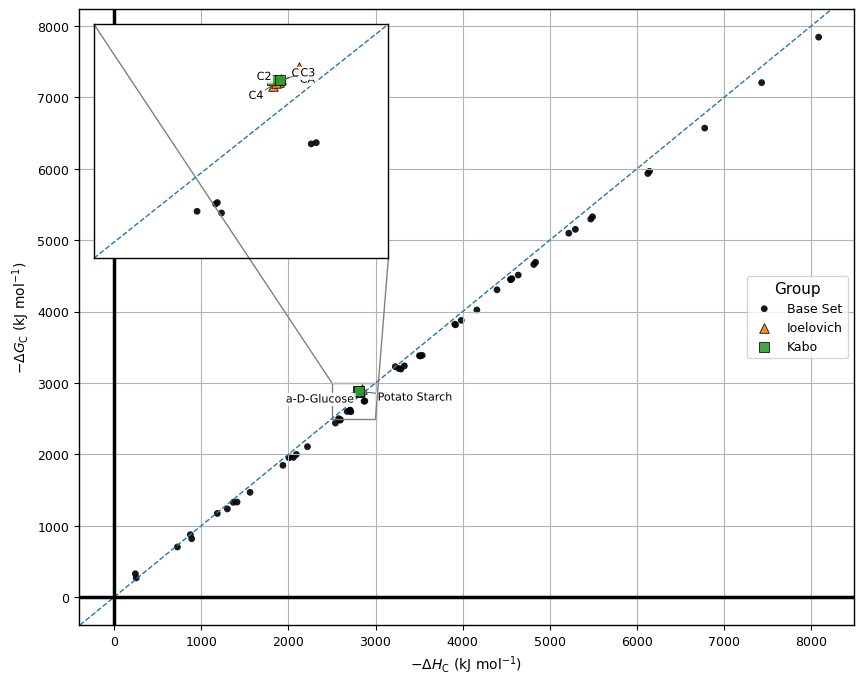

In [20]:
totORGc=totORGc.copy()
xcol, ycol, labelcol ="dH_rxn (kJ/mol)", "dG_rxn (kJ/mol)", "Compound"
group_sets = {
    "Domalski": {"Cellulose", "Lignin", "Xylan", "Starch", "Hemicellulose"}, 
    "Ioelovich": {"C1", "C2", "C3", "C4", "CA"}, 
    "Kabo": {"a-D-Glucose", "Potato Starch"}
}

def tag_row(name): 
    for grp, s in group_sets.items():
        if name in s: 
            return grp
    return "Base Set"

totORGc["group"] = totORGc["Compound"].map(tag_row)

palette = {
    "Domalski": "tab:blue", 
    "Ioelovich": "tab:orange", 
    "Kabo": "tab:green", 
    "Base Set": "black"
}
marker_map = {"Domalski": "o", "Ioelovich": "^", "Base Set": "o", "Kabo": "s"} #"Kabo": "s",
order = ["Base Set", "Domalski", "Ioelovich", "Kabo"] #"Kabo",
totORGc["group"] = pd.Categorical(totORGc["group"], categories=order, ordered=True)

include_groups = ["Base Set", "Ioelovich", "Kabo"]
plot_df = totORGc[totORGc["group"].isin(include_groups)].copy()

fig, ax = plt.subplots(figsize=(10,8))

for grp, sub in plot_df.groupby("group", observed=False): 
    if sub.empty: 
        continue
    ax.scatter(sub[xcol], sub[ycol], 
               label = grp, color = palette[grp], 
               marker=marker_map[grp],
               s=48 if grp !="Base Set" else 24, 
               alpha = 0.9,
               edgecolors="k" if grp != "Base Set" else "none", 
               linewidths=0.6 if grp != "Base Set" else 0)
    
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove any accidental dups
ax.legend(by_label.values(), by_label.keys(), title="Group", loc="center right", frameon=True)

assigned = annotate_groups_smart(ax, plot_df, ["Kabo"], xcol, ycol, labelcol, m, b, mag_pts=15)
for name, grp, dx, dy in assigned: 
    print(f"{name:20s} | {grp:9s} | dx={dx:5.1f}, dy={dy:5.1f}")

# reference lines
ax.axline((0, 0), slope=1, linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=2.5, zorder=10)
ax.axvline(0, color='black', linewidth=2.5, zorder=10)

# titles/labels
ax.set_xlabel(r"$-\Delta H_{\text{C}}$ (kJ mol$^{-1}$)")
ax.set_ylabel(r"$-\Delta G_{\text{C}}$ (kJ mol$^{-1}$)")
ax.grid(True, linewidth=0.8, color='0.7')

# --- inset (zoomed view) ---
axins = inset_axes(ax, width="38%", height="38%", loc="upper left", borderpad=1.2)

# Filter rows that fall inside the zoom box (once)
zoom_xlim=(2500, 3000)
zoom_ylim=(2500, 3000)
in_zoom = plot_df[xcol].between(*zoom_xlim) & plot_df[ycol].between(*zoom_ylim)
zoom_df = plot_df.loc[in_zoom]

# Plot inset points by group using the SAME palette/markers
for grp, sub in zoom_df.groupby("group", observed=False):
    if sub.empty:
        continue
    axins.scatter(
        sub[xcol], sub[ycol],
        c=palette.get(grp, "0.7"),
        marker=marker_map.get(grp, "o"),
        s=48 if grp != "Base Set" else 24,
        alpha=0.9,
        edgecolors="k" if grp != "Base Set" else "none",
        linewidths=0.6 if grp != "Base Set" else 0,
        label=grp
    )

annotate_inset_smart(axins, zoom_df, ["Ioelovich"], xcol, ycol, labelcol, m, b, mag_pts=8) #, "Kabo"

# Reference lines & axes cosmetics
axins.axline((0, 0), slope=1, linestyle="--", linewidth=1)
axins.axhline(0, linewidth=1.0)
axins.axvline(0, linewidth=1.0)

axins.set_xlim(*zoom_xlim)
axins.set_ylim(*zoom_ylim)
axins.set_xticks([])
axins.set_yticks([])

# If nothing landed in the zoom box, show a friendly note
if zoom_df.empty:
    axins.text(0.5, 0.5, "No points in\nzoom window",
               transform=axins.transAxes, ha="center", va="center", fontsize=8)

# Draw connectors from inset to the main plot region
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", lw=1)
# plt.savefig("IoeKaboCombPlot.png", dpi=1200, bbox_inches="tight")

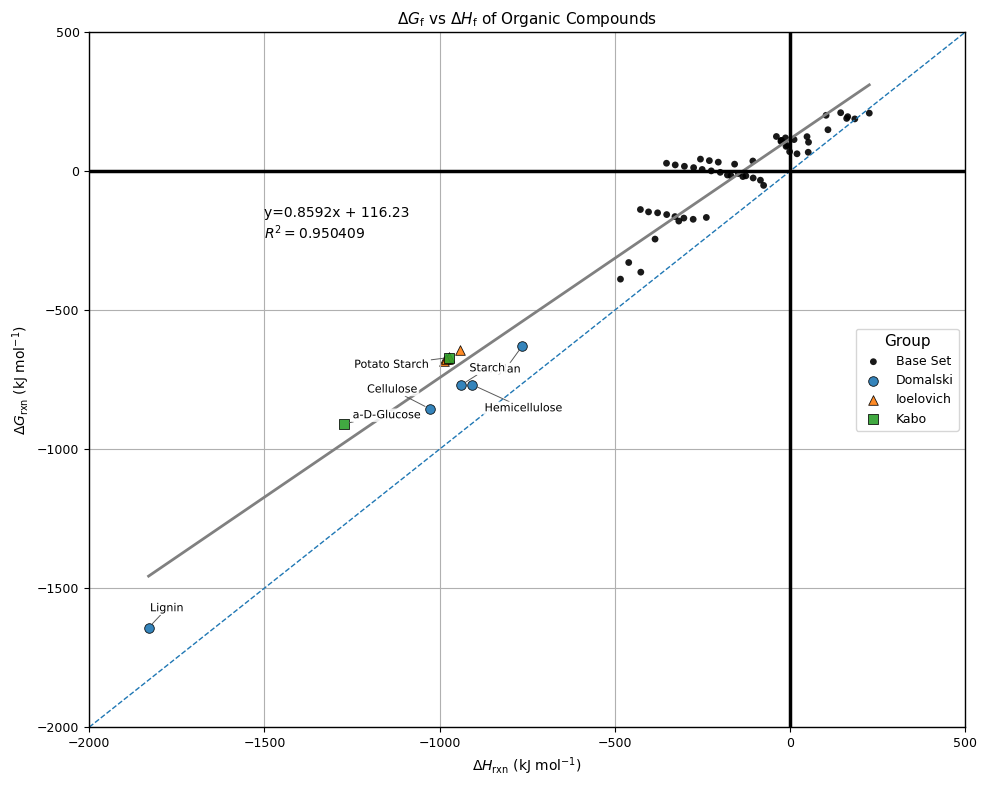

In [21]:
xcol="dH_F (kJ/mol)"
ycol="dG_F (kJ/mol)"
labelcol="Compound"
group_sets = {
    "Domalski": {"Cellulose", "Lignin", "Xylan", "Starch", "Hemicellulose"}, 
    "Ioelovich": {"C1", "C2", "C3", "C4", "CA"}, 
    "Kabo": {"a-D-Glucose", "Potato Starch"}
}

totORGc["group"] = totORGc["Compound"].map(tag_row)

palette = {
    "Domalski": "tab:blue", 
    "Ioelovich": "tab:orange", 
    "Kabo": "tab:green", 
    "Base Set": "black"
}
marker_map = {"Domalski": "o", "Ioelovich": "^", "Kabo": "s", "Base Set": "o"}
order = ["Base Set", "Domalski", "Ioelovich", "Kabo"]
totORGc["group"] = pd.Categorical(totORGc["group"], categories=order, ordered=True)

fig, ax = plt.subplots(figsize=(10,8))

for grp, sub in totORGc.groupby("group", observed=False): 
    if sub.empty: 
        continue
    ax.scatter(sub[xcol], sub[ycol], 
               label = grp, color = palette[grp], 
               marker=marker_map[grp],
               s=48 if grp !="Base Set" else 24, 
               alpha = 0.9,
               edgecolors="k" if grp != "Base Set" else "none", 
               linewidths=0.6 if grp != "Base Set" else 0)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove any accidental dups
ax.legend(by_label.values(), by_label.keys(), title="Group", loc="center right", frameon=True)

# Linear fit & R^2 (scipy only)
res = linregress(totORGc[xcol], totORGc[ycol])  # slope, intercept, rvalue, pvalue, stderr
m, b = res.slope, res.intercept
r2 = res.rvalue ** 2

# Trendline
xs = np.linspace(totORGc[xcol].min(), totORGc[xcol].max(), 200)
ax.plot(xs, m*xs + b, color='grey', lw=2, zorder=2)
ax.text(0.2, .75, f"y={m:.4f}x + {b:.2f}\n$R^2 = {r2:.6f}$",
           transform=ax.transAxes, va="top", fontsize=10)

annotate_groups_smart(ax, totORGc, ["Domalski", "Kabo"], xcol, ycol, labelcol, m, b, mag_pts=7)

plt.axline((0,0), slope=1, linestyle='--', linewidth=1)
plt.axhline(0, color='black', linewidth=2.5, zorder=10)
plt.axvline(0, color='black', linewidth=2.5, zorder=10)
plt.title("G_F vs H_F of Organic Compounds")
plt.xlabel('ΔH_F (kJ/mol)')
plt.ylabel('ΔG_F(kJ/mol)')
plt.title(r"$\Delta G_{\text{f}}$ vs $\Delta H_{\text{f}}$ of Organic Compounds")
plt.xlabel(r"$\Delta H_{\text{rxn}}$ (kJ mol$^{-1}$)")
plt.ylabel(r"$\Delta G_{\text{rxn}}$ (kJ mol$^{-1}$)")
plt.grid(True)
plt.xlim(-2000, 500)
plt.ylim(-2000, 500)
plt.tight_layout()
plt.show()